# Gradient descent and why we square the error

We want a **hyperplane** (here a line, i.e. a hyperplane in $\mathbb{R}^2$)

$$\hat{y} = w x + b$$

to fit data $(x_i, y_i)$. To pick good parameters we minimise a **cost
function** $J(w, b)$ that measures how far the model is from the data.

For gradient descent to converge to a (local) minimum, $J$ must be **convex**:
a smooth bowl where every local minimum is the global minimum. This notebook
shows the hyperplane, its cost surface, gradient descent walking downhill, and
why the error has to be **squared** to get a convex cost.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import FloatSlider, IntSlider, interact

rng = np.random.default_rng(42)
x = np.linspace(0, 1, 40)
true_w, true_b = 1.2, 0.3
y = true_w * x + true_b + rng.normal(0, 0.08, size=len(x))

In [2]:
def squared_cost(w, b):
    residual = y - (w * x + b)
    return float(np.mean(residual**2))


def absolute_cost(w, b):
    residual = y - (w * x + b)
    return float(np.mean(np.abs(residual)))


def squared_gradient(w, b):
    residual = y - (w * x + b)
    gw = -2.0 * np.mean(residual * x)
    gb = -2.0 * np.mean(residual)
    return gw, gb

## 1. The hyperplane and its residuals

Slide `w` and `b` to move the line over the data. The vertical red segments are
the residuals $y_i - \hat{y}_i$ that the cost function squares.

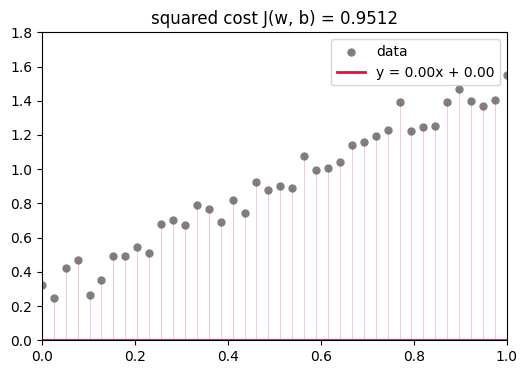

interactive(children=(FloatSlider(value=0.0, description='slope w', max=3.0, min=-2.0, step=0.05), FloatSlider…

In [3]:
@interact(
    w=FloatSlider(min=-2, max=3, step=0.05, value=0.0, description="slope w"),
    b=FloatSlider(
        min=-1, max=1.5, step=0.05, value=0.0, description="intercept b"
    ),
)
def plot_hyperplane(w, b):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x, y, s=25, color="tab:gray", label="data")
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs, w * xs + b, color="crimson", lw=2, label=f"y = {w:.2f}x + {b:.2f}"
    )
    for xi, yi in zip(x, y, strict=False):
        ax.plot([xi, xi], [yi, w * xi + b], color="crimson", lw=0.4, alpha=0.4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.8)
    ax.set_title(f"squared cost J(w, b) = {squared_cost(w, b):.4f}")
    ax.legend()
    plt.show()

## 2. The cost surface is a convex bowl

Plotting the squared cost over every $(w, b)$ gives a quadratic surface with a
single minimum (black dot). A function like this, where the line between any two
points stays above the function, is **convex** — any local minimum is the global
minimum, so downhill search always lands in the optimum.

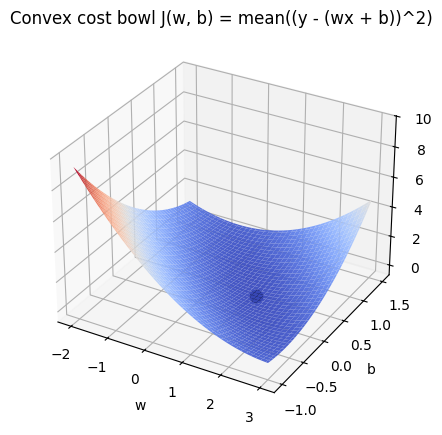

In [4]:
w_star = np.cov(x, y)[0, 1] / np.var(x)
b_star = y.mean() - w_star * x.mean()

ws = np.linspace(-2, 3, 80)
bs = np.linspace(-1, 1.5, 80)
W, B = np.meshgrid(ws, bs)
Z = np.array(
    [squared_cost(w, b) for w, b in zip(W.ravel(), B.ravel(), strict=False)]
).reshape(W.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, Z, cmap="coolwarm", alpha=0.95)
ax.scatter(w_star, b_star, squared_cost(w_star, b_star), color="black", s=80)
ax.set_title("Convex cost bowl J(w, b) = mean((y - (wx + b))^2)")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J")
plt.show()

## 3. Gradient descent walks downhill

Gradient descent starts at some $(w, b)$ and repeatedly steps against the
gradient of $J$:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \qquad
  b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Because the bowl is convex, every step reduces $J$ and the walk converges to the
unique minimum. Drag the step slider to watch the descent.

Task was destroyed but it is pending!
task: <Task pending name='Task-42' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/mlops-venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-43' coro=<Kernel.shell_main() running at /opt/mlops-venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/mlops-venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>


/opt/mlops-venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:403: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  iter(y)
Task was destroyed but it is pending!
task: <Task pending name='Task-43' coro=<Kernel.shell_main() running at /opt/mlops-venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


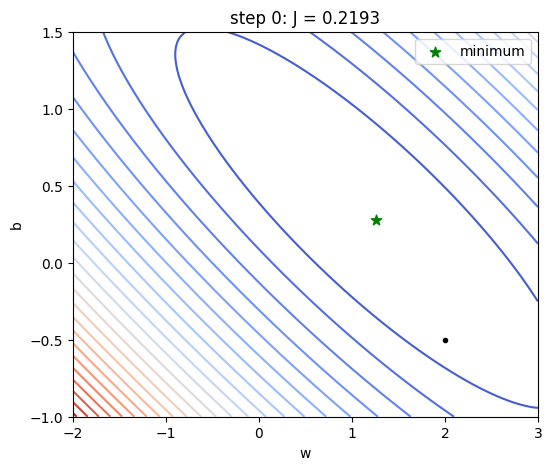

interactive(children=(IntSlider(value=0, description='step', max=40), Output()), _dom_classes=('widget-interac…

In [5]:
def run_gradient_descent(w0, b0, alpha=0.5, steps=40):
    w, b = w0, b0
    trail = [(w, b)]
    for _ in range(steps):
        gw, gb = squared_gradient(w, b)
        w -= alpha * gw
        b -= alpha * gb
        trail.append((w, b))
    return np.array(trail)


trail = run_gradient_descent(2.0, -0.5)


@interact(
    step=IntSlider(
        min=0, max=len(trail) - 1, step=1, value=0, description="step"
    )
)
def show_step(step):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contour(W, B, Z, levels=25, cmap="coolwarm")
    ax.plot(
        trail[: step + 1, 0],
        trail[: step + 1, 1],
        color="black",
        lw=1.5,
        marker="o",
        ms=3,
    )
    ax.scatter(
        w_star, b_star, color="green", s=60, marker="*", label="minimum"
    )
    ax.set_title(f"step {step}: J = {squared_cost(*trail[step]):.4f}")
    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.legend()
    plt.show()

## 4. Why square the error?

Slicing the cost along $w$ (with $b$ fixed) shows the difference between the two
candidates:

- **Squared error** $J_2(w) = \frac{1}{n}\sum_i (y_i - (w x_i + b))^2$ is a
  **parabola**: smooth and convex, with one minimum. Its gradient vanishes
  gradually as $w$ approaches the optimum, so gradient descent slows down and
  settles exactly on the minimum.
- **Absolute error** $J_1(w) = \frac{1}{n}\sum_i |y_i - (w x_i + b)|$ has a
  **kink** at the optimum: it is not differentiable there, and away from it the
  gradient has constant magnitude — the step size never shrinks, so descent
  overshoots and oscillates around the minimum instead of converging to it. For
  non-linear models the absolute value need not even be convex, in which case
  gradient descent can stop in a spurious local minimum.

Squaring is what turns the non-smooth "V" into the smooth convex bowl: a unique
local (= global) minimum that gradient descent is guaranteed to converge to.

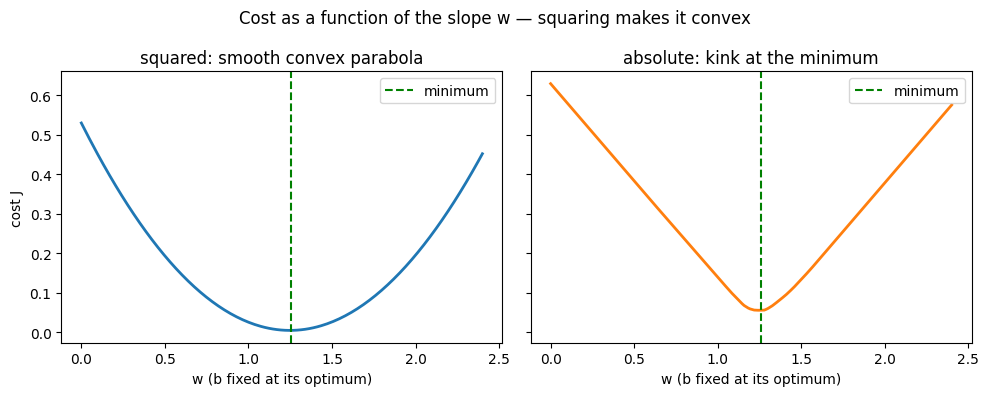

In [6]:
w_range = np.linspace(0, 2.4, 200)
j_squared = np.array([squared_cost(w, b_star) for w in w_range])
j_absolute = np.array([absolute_cost(w, b_star) for w in w_range])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1.plot(w_range, j_squared, color="tab:blue", lw=2)
ax1.set_title("squared: smooth convex parabola")
ax1.axvline(w_star, color="green", ls="--", label="minimum")
ax1.set_xlabel("w (b fixed at its optimum)")
ax1.legend()
ax2.plot(w_range, j_absolute, color="tab:orange", lw=2)
ax2.set_title("absolute: kink at the minimum")
ax2.axvline(w_star, color="green", ls="--", label="minimum")
ax2.set_xlabel("w (b fixed at its optimum)")
ax2.legend()
ax1.set_ylabel("cost J")
fig.suptitle("Cost as a function of the slope w — squaring makes it convex")
plt.tight_layout()
plt.show()

## 5. Convergence depends on the learning rate

Even on a convex bowl the step size matters. Try raising $\alpha$: too large and
the walk overshoots across the bowl and diverges; too small and it converges but
slowly. The right panel shows the cost per step on a log scale.

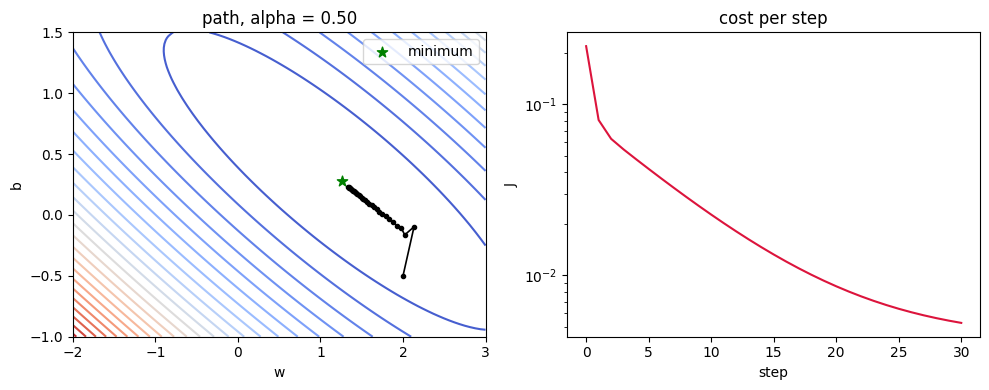

interactive(children=(FloatSlider(value=0.5, description='learning rate', max=1.2, min=0.05, step=0.05), IntSl…

In [7]:
@interact(
    alpha=FloatSlider(
        min=0.05, max=1.2, step=0.05, value=0.5, description="learning rate"
    ),
    steps=IntSlider(min=1, max=60, value=30, description="steps"),
)
def animate_descent(alpha, steps):
    trial = run_gradient_descent(2.0, -0.5, alpha=alpha, steps=steps)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.contour(W, B, Z, levels=25, cmap="coolwarm")
    ax1.plot(trial[:, 0], trial[:, 1], color="black", marker="o", ms=3, lw=1.2)
    ax1.scatter(
        w_star, b_star, color="green", s=60, marker="*", label="minimum"
    )
    ax1.set_title(f"path, alpha = {alpha:.2f}")
    ax1.set_xlabel("w")
    ax1.set_ylabel("b")
    ax1.legend()
    costs = [squared_cost(w, b) for w, b in trial]
    ax2.plot(np.arange(len(trial)), costs, color="crimson", lw=1.5)
    ax2.set_title("cost per step")
    ax2.set_xlabel("step")
    ax2.set_ylabel("J")
    ax2.set_yscale("log")
    plt.tight_layout()
    plt.show()